In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

df = pd.read_csv("student-mat.csv", sep=";")   #delimiter is the semicolon
print(df.shape, df.isna().sum().sum())

(395, 33) 0


In [2]:
num_cols = ["age", "studytime", "failures", "absences", "G1", "G2", "G3"]
df[num_cols].agg(["mean", "median", "std"]).round(2)

,age,studytime,failures,absences,G1,G2,G3
mean,16.70,2.04,0.33,5.71,10.91,10.71,10.42
median,17.00,2.00,0.00,4.00,11.00,11.00,11.00
std,1.28,0.84,0.74,8.00,3.32,3.76,4.58


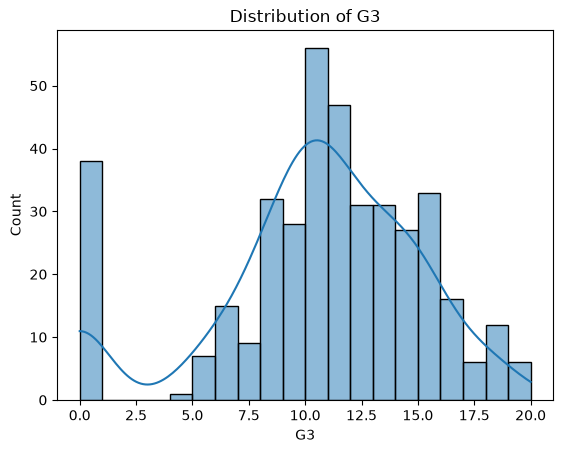

In [3]:
sns.histplot(df["G3"], bins=20, kde=True)
plt.title("Distribution of G3")
plt.show()

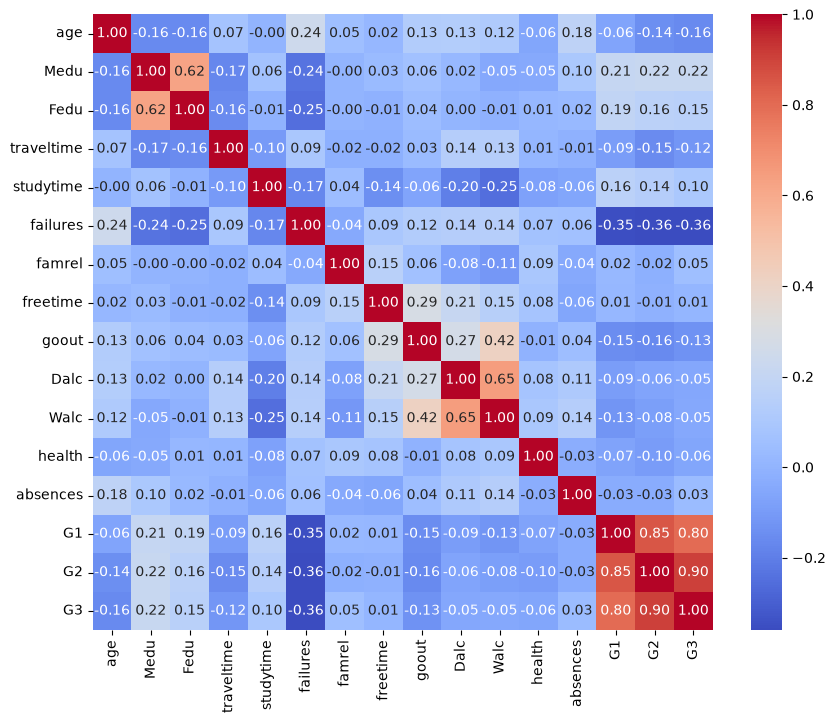

In [4]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

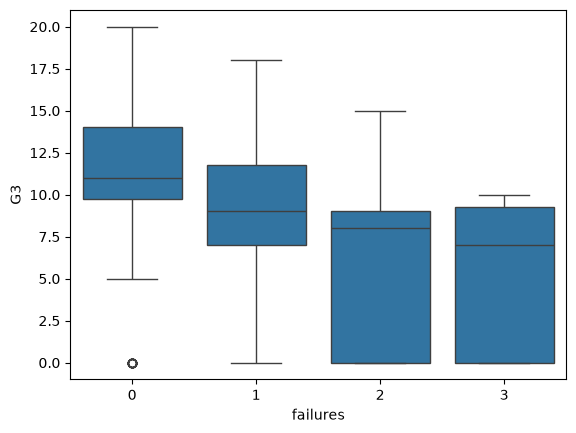

In [5]:
sns.boxplot(x="failures", y="G3", data=df)
plt.show()

I noticed that G3's median is higher than the mean of the data set and there is a distinct cluster of zeros that could represent students who have dropped out or skipped the final exam. G1 and G2 are the strongest correlates of G3 (roughly 0.80 and 0.90), which means if a student scores well in G1 and G2, it is most likely that they will have a good score for G3. The heat map proves this as each red square represents two variables that correlate strongly; if one goes up, the other goes up as well. Failures has a moderate negative correlation with G3 (about -0.36), and the boxplot shows students with no past failures have a clearly higher median grade than those with one or more. In contrast, studytime is only weakly positive and absences is close to zero, so neither is a strong predictor on its own. Absences is also right-skewed (mean above median), since most students miss few classes while a small number miss many.

Task 3: Model Training and Evaluation

In [ ]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from task2_preprocessing import (
    TrainingPreprocessor,
    load_student_math,
    split_features_target,
)

data = load_student_math("student-mat.csv")
X, y = split_features_target(data)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

preprocessor = TrainingPreprocessor.fit(X_train)
X_train_ready = preprocessor.transform(X_train)
X_test_ready = preprocessor.transform(X_test)
print(X_train_ready.shape, X_test_ready.shape)

(316, 41) (79, 41)


In [7]:
for d in [2, 3, 4, 5, 8, None]:
    m = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_train_ready, y_train)
    print(d, "train R2:", round(m.score(X_train_ready, y_train), 3),
          "test R2:", round(m.score(X_test_ready, y_test), 3))

2 train R2: 0.756 test R2: 0.731
3 train R2: 0.879 test R2: 0.771
4 train R2: 0.93 test R2: 0.698
5 train R2: 0.966 test R2: 0.703
8 train R2: 0.997 test R2: 0.728
None train R2: 1.0 test R2: 0.795


In [ ]:
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt.fit(X_train_ready, y_train)
dt_pred = dt.predict(X_test_ready)

print("MSE:", mean_squared_error(y_test, dt_pred))
print("R2:", r2_score(y_test, dt_pred))

MSE: 5.584041866823252
R2: 0.7276747625195831


In [9]:
X_no = X.drop(columns=["G1", "G2"])
Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_no, y, test_size=0.20, random_state=42
)
pre_no = TrainingPreprocessor.fit(Xn_train)
Xn_train_ready = pre_no.transform(Xn_train)
Xn_test_ready = pre_no.transform(Xn_test)

dt_no = DecisionTreeRegressor(max_depth=5, random_state=42).fit(Xn_train_ready, yn_train)
dt_no_pred = dt_no.predict(Xn_test_ready)
print("No G1/G2 -> MSE:", mean_squared_error(yn_test, dt_no_pred),
      "R2:", r2_score(yn_test, dt_no_pred))

No G1/G2 -> MSE: 20.038794021694816 R2: 0.022738462402733917


I implemented a Decision Tree Regressor to predict the final grade 'G3'. A decision tree can capture non-linear relationships and interactions between features. The data split was 80/20 percent. I used a max_depth of 8, with requiring scaled inputs the data was split 80/20 with `random_state=42`, giving 316 training rows and 79 test rows. This is a common ratio that leaves enough data to train on while keeping a reasonable test set. Preprocessing was fitted on the training set only to avoid data leakage. Test MSE was caculated to be: 5.58 and the test R^2: .728. An R² of about 0.73 means the model explains roughly 73% of the variance in final grades, which falls in the 0.6-0.85. The given range gives a reasonable indicator that we have an accurate set of data. An MSE of 5.58 corresponds to a typical error of about 2.4 grade points on the 0-20 scale.Comparing depths showed a clear gap between training and test performance. At depth 8, training R² was 0.997 versus a test R² of 0.728, so the tree has largely memorized the training data. Shallower trees generalized about as well or better (depth 3 reached a test R² of 0.771 with a much smaller train/test gap), which suggests that a simpler tree would be a more reliable choice than depth 8.

In [10]:
results = pd.DataFrame({
    "actual": y_test.values,
    "predicted_with_G1G2": dt_pred,
    "predicted_no_G1G2": dt_no_pred,
})
results.to_csv("predictions.csv", index=False)
results.head()

,actual,predicted_with_G1G2,predicted_no_G1G2
0,10,8.000000,8.111111
1,12,12.000000,11.228261
2,5,8.000000,10.937500
3,10,9.928571,11.228261
4,9,9.111111,8.111111


## 4. Model Performance Visualization

The following plot compares the actual test grades with the predictions from the model that includes G1 and G2. The dashed line represents a perfect prediction.


MSE: 5.584
R squared: 0.728


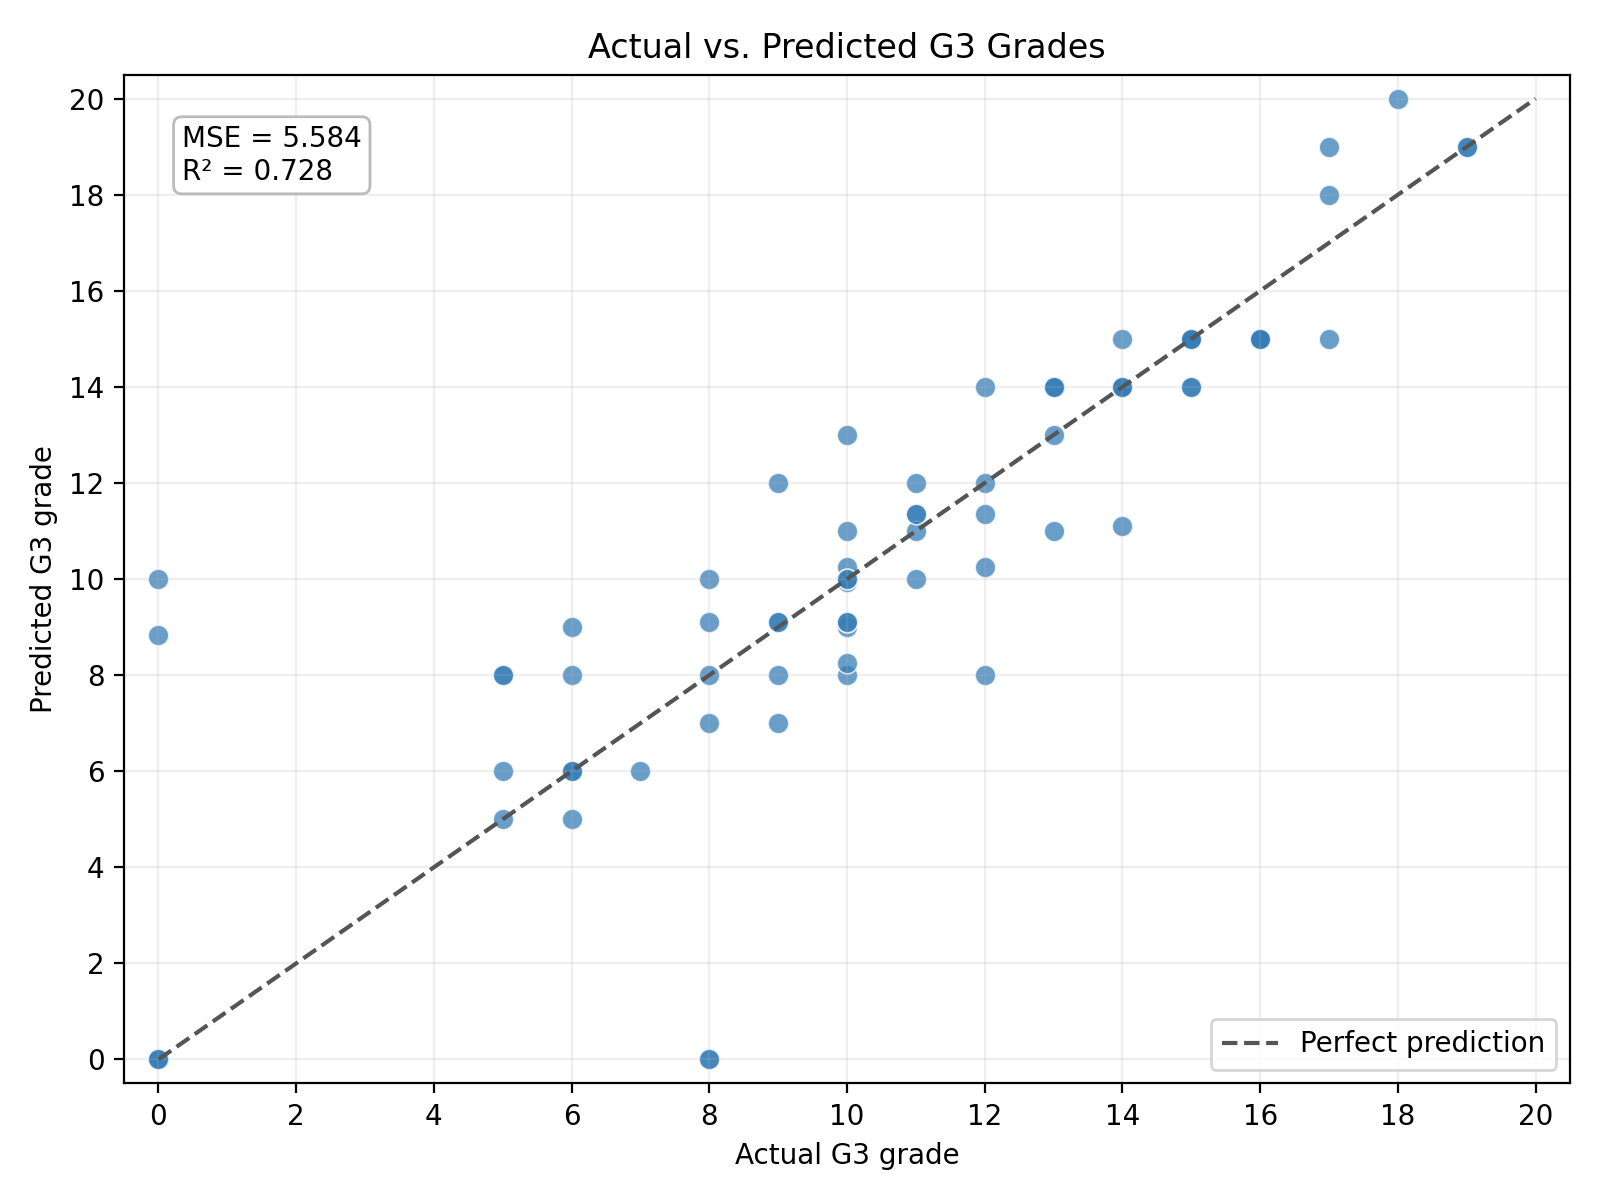

In [6]:
from sklearn.metrics import mean_squared_error, r2_score

# Load the predictions made in Task 3
results = pd.read_csv("predictions.csv")
actual = results["actual"]
predicted = results["predicted_with_G1G2"]

mse = mean_squared_error(actual, predicted)
r2 = r2_score(actual, predicted)

print(f"MSE: {mse:.3f}")
print(f"R squared: {r2:.3f}")

plt.figure(figsize=(8, 6))
plt.scatter(actual, predicted, color="#377eb8", alpha=0.75,
            s=55, edgecolors="white", linewidth=0.6)
plt.plot([0, 20], [0, 20], "--", color="#555555",
         label="Perfect prediction")

plt.xlim(-0.5, 20.5)
plt.ylim(-0.5, 20.5)
plt.xticks(range(0, 21, 2))
plt.yticks(range(0, 21, 2))
plt.xlabel("Actual G3 grade")
plt.ylabel("Predicted G3 grade")
plt.title("Actual vs. Predicted G3 Grades")
plt.grid(alpha=0.2)
plt.legend(loc="lower right")

score_text = f"MSE = {mse:.3f}\nR² = {r2:.3f}"
plt.text(0.04, 0.95, score_text, transform=plt.gca().transAxes,
         va="top", bbox=dict(boxstyle="round", facecolor="white",
                              edgecolor="#bbbbbb"))
plt.tight_layout()
plt.show()


### Task 4 observations

The points mostly follow the dashed line, especially for grades between 8 and 15. The model got an R squared value of **0.728**, so it explains about **72.8%** of the differences in final grades. Its MSE was **5.584**. The model had more trouble with some of the zero grades, which is where a few of the largest errors appear. Overall, the predictions look reasonable, but the model is less accurate for some of the grades at the low end.
